In [78]:
import pandas as pd
import numpy as np

In [79]:
DATA_PATH = "https://raw.githubusercontent.com/onurvatansever/bdt-odev01/main/data/Sleep_health_and_lifestyle_dataset.csv"

df = pd.read_csv(DATA_PATH)

In [80]:
df.head(20)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [82]:
from sklearn.preprocessing import LabelEncoder

df['Occupation'] = df['Occupation'].fillna('None')
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
df[['SBP', 'DBP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Person ID', 'Blood Pressure'], inplace=True)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

le = LabelEncoder()
df['BMI Category'] = le.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])
df = pd.get_dummies(df, columns=['Occupation'], dtype=int)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           374 non-null    int64  
 1   Age                              374 non-null    int64  
 2   Sleep Duration                   374 non-null    float64
 3   Quality of Sleep                 374 non-null    int64  
 4   Physical Activity Level          374 non-null    int64  
 5   Stress Level                     374 non-null    int64  
 6   BMI Category                     374 non-null    int64  
 7   Heart Rate                       374 non-null    int64  
 8   Daily Steps                      374 non-null    int64  
 9   Sleep Disorder                   374 non-null    int64  
 10  SBP                              374 non-null    int64  
 11  DBP                              374 non-null    int64  
 12  Occupation_Accountant 

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['Quality of Sleep'])
y = df['Quality of Sleep']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

--- Uykuyu En Çok Etkileyen Faktörler ---
                         Faktör  Önem_Derecesi
                 Sleep Duration       0.789979
                   Stress Level       0.105660
              Occupation_Doctor       0.036277
                     Heart Rate       0.032033
                            Age       0.008922
                    Daily Steps       0.008888
          Occupation_Accountant       0.005410
                   BMI Category       0.003596
                            DBP       0.002313
            Occupation_Engineer       0.001259
        Physical Activity Level       0.001079
           Occupation_Scientist       0.000964
                            SBP       0.000923
                 Sleep Disorder       0.000803
             Occupation_Teacher       0.000781
              Occupation_Lawyer       0.000567
               Occupation_Nurse       0.000202
                         Gender       0.000174
         Occupation_Salesperson       0.000101
             Occup

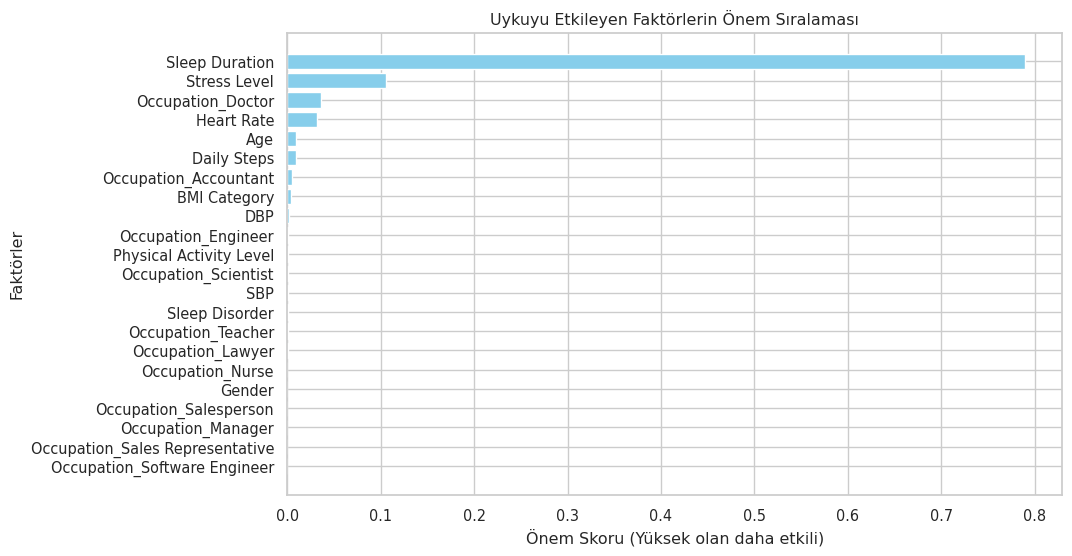

In [88]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Faktör': features,
    'Önem_Derecesi': importances
}).sort_values(by='Önem_Derecesi', ascending=False)
import matplotlib.pyplot as plt
# 6. Sonucu Ekrana Yazdırma
print("--- Uykuyu En Çok Etkileyen Faktörler ---")
print(importance_df.to_string(index=False))

print(f"\nEn çok etkileyen faktör: {importance_df.iloc[0]['Faktör']}")

# 7. Görselleştirme (Grafik)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Faktör'], importance_df['Önem_Derecesi'], color='skyblue')
plt.xlabel('Önem Skoru (Yüksek olan daha etkili)')
plt.ylabel('Faktörler')
plt.title('Uykuyu Etkileyen Faktörlerin Önem Sıralaması')
plt.gca().invert_yaxis() # En önemki faktörü en üstte göstermek için
plt.show()